## AI 数学基础

### KL散度与交叉熵：
1. **KL 散度**（Kullback-Leibler Divergence）：
   $$
   D_{KL}(P || Q) = \sum_{i} P(i) \log \frac{P(i)}{Q(i)}
   $$
   $$
   D_{KL}(Q || P) = \sum_{i} Q(i) \log \frac{Q(i)}{P(i)}
   $$

2. **交叉熵**（Cross Entropy）：
   $$
   H(Q, P) = -\sum_{i} Q(i) \log P(i)
   $$


In [1]:
import numpy as np

# 定义两个离散分布 p 和 q
p = np.array([0.2, 0.3, 0.4, 0.1])
q = np.array([0.1, 0.2, 0.4, 0.3])

# 计算 KL 散度 D_KL(q || p)
D_KL_q_p = np.sum(q * np.log(q / p))

# 计算 KL 散度 D_KL(p || q)
D_KL_p_q = np.sum(p * np.log(p / q))

# 计算 CrossEntropy(q, p)
cross_entropy_q_p = -np.sum(q * np.log(p))

print("KL 散度 D_KL(q || p)：", D_KL_q_p)
print("KL 散度 D_KL(p || q)：", D_KL_p_q)
print("CrossEntropy(q, p)：", cross_entropy_q_p)

KL 散度 D_KL(q || p)： 0.17917594692280547
KL 散度 D_KL(p || q)： 0.15040773967762736
CrossEntropy(q, p)： 1.459030172756473


### 反向传播
假设一个三层神经网络（两个隐藏层）有以下结构：
- 输入层：特征维度为 $d$ ，输入为 $x \in \mathbb{R}^d$
- 第一隐藏层：有 $h_1$ 个神经元，激活函数为 $\sigma$ ，权重矩阵为 $W_1 \in \mathbb{R}^{h_1 \times d}$
- 第二隐藏层：有 $h_2$ 个神经元，激活函数为 $\sigma$ ，权重矩阵为 $W_2 \in \mathbb{R}^{h_2 \times h_1}$
- 输出层：有 $d^{\prime}$ 个神经元，无激活函数，权重矩阵为 $W_3 \in \mathbb{R}^{d^{\prime} \times h_2}$

第一隐藏层的輸出：
第二隐藏层的输出：

$$
\begin{array}{ll}
z_1=W_1 x \in \mathbb{R}^{h_1}, & a_1=\sigma\left(z_1\right) \in \mathbb{R}^{h_1} \\
z_2=W_2 a_1 \in \mathbb{R}^{h_2}, & a_2=\sigma\left(z_2\right) \in \mathbb{R}^{h_2}
\end{array}
$$


输出层的输出：
为了简单，考虑如下损失函数：

$$
\hat{y}=z_3=W_3 a_2 \in \mathbb{R}^{d^{\prime}}
$$


$$
L=\frac{1}{2}\|\widehat{y}-y\|_2^2
$$

**输出层的梯度计算：**

损失函数对输出层的输出 $z_3$ 的梯度，$z_3 \in \mathbb{R}^{d^{\prime}}$ ：

$$
\frac{\partial L}{\partial z_3}=\hat{y}-\mathrm{y} \in \mathbb{R}^{d^{\prime}}
$$


损失函数对 $W_3$ 的梯度（链式法则），$W_3 \in \mathbb{R}^{d^{\prime} \times h_2}$ ：

$$
\frac{\partial L}{\partial W_3}=\frac{\partial L}{\partial z_3} \frac{\partial z_3}{\partial W_3}=(\hat{y}-\mathrm{y}) a_2^{\top} \in \mathbb{R}^{d^{\prime} \times h_2}
$$


损失函数对 $a_2$ 的梯度，$a_2 \in \mathbb{R}^{h_2}$ ：

$$
\frac{\partial L}{\partial a_2}=\frac{\partial L}{\partial z_3} \frac{\partial z_3}{\partial a_2}=W_3^{\top}(\hat{y}-\mathrm{y}) \in \mathbb{R}^{h_2}
$$

**第二隐藏层的梯度计算：**

损失函数对 $z_2$ 的梯度，$z_2 \in \mathbb{R}^{h_2}$ ：

$$
\frac{\partial L}{\partial z_2}=\frac{\partial L}{\partial a_2} \frac{\partial a_2}{\partial z_2}=W_3^{\top}(\hat{y}-\mathrm{y}) \odot \sigma^{\prime}\left(z_2\right) \in \mathbb{R}^{h_2}
$$


其中 $\odot$ 表示两个对象逐元素相乘
损失函数对 $W_2$ 的梯度，$W_2 \in \mathbb{R}^{h_2 \times h_1}$ ：

$$
\frac{\partial L}{\partial W_2}=\frac{\partial L}{\partial z_2} \frac{\partial z_2}{\partial W_2}=\left[W_3^{\top}(\hat{y}-y) \odot \sigma^{\prime}\left(z_2\right)\right] a_1^{\top} \in \mathbb{R}^{h_2 \times h_1}
$$


损失函数对 $a_1$ 的梯度，$a_2 \in \mathbb{R}^{h_1}$ ：

$$
\frac{\partial L}{\partial a_1}=\frac{\partial L}{\partial z_2} \frac{\partial z_2}{\partial a_1}=W_2^{\top}\left[W_3^{\top}(\hat{y}-y) \odot \sigma^{\prime}\left(z_2\right)\right] \in \mathbb{R}^{h_1}
$$

**第一隐藏层的梯度计算：**

损失函数对 $z_1$ 的梯度，$z_1 \in \mathbb{R}^{h_1}$ ：

$$
\frac{\partial L}{\partial z_1}=\frac{\partial L}{\partial a_1} \frac{\partial a_1}{\partial z_1}=\left[W_2^{\top}\left[W_3^{\top}(\hat{y}-y) \odot \sigma^{\prime}\left(z_2\right)\right]\right] \odot \sigma^{\prime}\left(z_1\right) \in \mathbb{R}^{h_1}
$$


其中 $\odot$ 表示两个对象逐元素相乘
损失函数对 $W_1$ 的梯度，$W_1 \in \mathbb{R}^{h_1 \times d}$ ：

$$
\frac{\partial L}{\partial W_1}=\frac{\partial L}{\partial z_1} \frac{\partial z_1}{\partial W_1}=\left[\left[W_2^{\top}\left[W_3^{\top}(\hat{y}-y) \odot \sigma^{\prime}\left(z_2\right)\right]\right] \odot \sigma^{\prime}\left(z_1\right)\right] x^{\top} \in \mathbb{R}^{h_1 \times d}
$$

In [2]:
import torch

# 定义激活函数及其导数
def sigmoid(x):
    return 1 / (1 + torch.exp(-x))

def sigmoid_derivative(x):
    sig = sigmoid(x)
    return sig * (1 - sig)

# 初始化参数
torch.manual_seed(42)  # 设置随机种子保证可复现

d = 4  # 输入维度
h1 = 5  # 第一隐藏层神经元数
h2 = 3  # 第二隐藏层神经元数
d_out = 2  # 输出层神经元数

# 随机初始化权重
W1 = torch.randn(h1, d, requires_grad=True)
W2 = torch.randn(h2, h1, requires_grad=True)
W3 = torch.randn(d_out, h2, requires_grad=True)

# 随机初始化输入和真实标签
x = torch.randn(d, requires_grad=False)
y = torch.randn(d_out, requires_grad=False)

# 前向传播计算
z1 = W1 @ x
a1 = sigmoid(z1)

z2 = W2 @ a1
a2 = sigmoid(z2)

z3 = W3 @ a2
y_hat = z3  # 无激活函数

# 计算损失
loss = 0.5 * torch.norm(y_hat - y) ** 2

In [3]:
# 计算输出层梯度
dL_dz3 = y_hat - y  # ∂L/∂z3
dL_dW3 = dL_dz3.view(-1, 1) @ a2.view(1, -1)  # ∂L/∂W3
dL_da2 = W3.T @ dL_dz3  # ∂L/∂a2

# 计算第二隐藏层梯度
dL_dz2 = dL_da2 * sigmoid_derivative(z2)  # ∂L/∂z2
dL_dW2 = dL_dz2.view(-1, 1) @ a1.view(1, -1)  # ∂L/∂W2
dL_da1 = W2.T @ dL_dz2  # ∂L/∂a1

# 计算第一隐藏层梯度
dL_dz1 = dL_da1 * sigmoid_derivative(z1)  # ∂L/∂z1
dL_dW1 = dL_dz1.view(-1, 1) @ x.view(1, -1)  # ∂L/∂W1

In [4]:
# 计算 PyTorch 自动梯度
# 清除梯度
W1.grad = None
W2.grad = None
W3.grad = None
loss.backward()

# 获取 PyTorch 计算的梯度
grad_W1_torch = W1.grad.clone()
grad_W2_torch = W2.grad.clone()
grad_W3_torch = W3.grad.clone()

# 比较手动计算的梯度和 PyTorch 计算的梯度
print("手动计算的 ∂L/∂W1：\n", dL_dW1)
print("PyTorch 计算的 ∂L/∂W1：\n", grad_W1_torch)

print("\n手动计算的 ∂L/∂W2：\n", dL_dW2)
print("PyTorch 计算的 ∂L/∂W2：\n", grad_W2_torch)

print("\n手动计算的 ∂L/∂W3：\n", dL_dW3)
print("PyTorch 计算的 ∂L/∂W3：\n", grad_W3_torch)

手动计算的 ∂L/∂W1：
 tensor([[ 0.0091,  0.0043, -0.0019, -0.0068],
        [ 0.0800,  0.0378, -0.0165, -0.0598],
        [-0.1103, -0.0521,  0.0228,  0.0824],
        [ 0.0613,  0.0290, -0.0127, -0.0459],
        [ 0.0226,  0.0107, -0.0047, -0.0169]], grad_fn=<MmBackward0>)
PyTorch 计算的 ∂L/∂W1：
 tensor([[ 0.0091,  0.0043, -0.0019, -0.0068],
        [ 0.0800,  0.0378, -0.0165, -0.0598],
        [-0.1103, -0.0521,  0.0228,  0.0824],
        [ 0.0613,  0.0290, -0.0127, -0.0459],
        [ 0.0226,  0.0107, -0.0047, -0.0169]])

手动计算的 ∂L/∂W2：
 tensor([[-0.3343, -0.0546, -0.1663, -0.1059, -0.1536],
        [ 0.3383,  0.0552,  0.1683,  0.1072,  0.1555],
        [ 0.4611,  0.0753,  0.2294,  0.1461,  0.2119]], grad_fn=<MmBackward0>)
PyTorch 计算的 ∂L/∂W2：
 tensor([[-0.3343, -0.0546, -0.1663, -0.1059, -0.1536],
        [ 0.3383,  0.0552,  0.1683,  0.1072,  0.1555],
        [ 0.4611,  0.0753,  0.2294,  0.1461,  0.2119]])

手动计算的 ∂L/∂W3：
 tensor([[-0.5561, -0.8548, -0.6943],
        [-1.0307, -1.5843, -1.2869

## MNIST 案例

In [27]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. 数据准备 (Data Preparation)
# ==========================================
print("正在加载 MNIST 数据（第一次需要下载）...")

# 定义转换：转为 Tensor -> 展平 (28x28=784)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: torch.flatten(x))
])

# 下载完整数据集
full_train_set = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
full_test_set = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# --- 课堂演示优化：可以只截取一部分数据 (Lite Version) ---
# 训练集：50000张，测试集：10000张
train_size = 50000   # 演示时可以适当调小以加快训练速度
test_size = 10000 # 演示时可以适当调小以加快训练速度

X_train = torch.stack([full_train_set[i][0] for i in range(train_size)])
y_train = torch.tensor([full_train_set[i][1] for i in range(train_size)])

X_test = torch.stack([full_test_set[i][0] for i in range(test_size)])
y_test = torch.tensor([full_test_set[i][1] for i in range(test_size)])

print(f"数据准备完毕: 训练集 {X_train.shape}, 测试集 {X_test.shape}")
print("注意：数据已归一化到 [0, 1] 区间 (x / 255.0)")

# ==========================================
# 2. 模型与参数初始化 (Math & Model)
# ==========================================
torch.manual_seed(42)

# 超参数
INPUT_DIM = 784
HIDDEN_DIM = 128
OUTPUT_DIM = 10
LEARNING_RATE = 0.1
BATCH_SIZE = 128
EPOCHS = 2  # 稍微增加轮数以观察曲线

# 初始化参数 (He Initialization)
# W ~ N(0, 2/n_in)，保持信号强度稳定
W1 = torch.randn(INPUT_DIM, HIDDEN_DIM) * (2. / INPUT_DIM)**0.5
b1 = torch.zeros(HIDDEN_DIM)
W2 = torch.randn(HIDDEN_DIM, OUTPUT_DIM) * (2. / HIDDEN_DIM)**0.5
b2 = torch.zeros(OUTPUT_DIM)

# 历史记录 (用于绘图) - 改为记录每个 step
history = {'step': [], 'train_loss': [], 'test_loss': [], 'test_acc': []}

# ==========================================
# 3. 核心数学函数 (Math Functions)
# ==========================================
def relu(z):
    return torch.maximum(z, torch.tensor(0.0))

def relu_derivative(z):
    return (z > 0).float()

def softmax(z):
    # 减去最大值以保证数值稳定性 (防止 exp 溢出)
    z_stable = z - torch.max(z, dim=1, keepdim=True).values
    exp_z = torch.exp(z_stable)
    return exp_z / torch.sum(exp_z, dim=1, keepdim=True)

def cross_entropy(y_hat, y_true):
    """
    y_hat: (batch, 10) 预测概率
    y_true: (batch,) 真实标签索引
    """
    m = y_true.shape[0]
    p = y_hat[range(m), y_true]
    log_p = -torch.log(p + 1e-9)
    return torch.sum(log_p) / m

def accuracy(y_hat, y_true):
    preds = torch.argmax(y_hat, dim=1)
    return (preds == y_true).float().mean()

def evaluate_on_test():
    """在测试集上评估当前模型"""
    z1_test = X_test @ W1 + b1
    a1_test = relu(z1_test)
    z2_test = a1_test @ W2 + b2
    y_hat_test = softmax(z2_test)
    
    test_loss = cross_entropy(y_hat_test, y_test).item()
    test_acc = accuracy(y_hat_test, y_test).item()
    return test_loss, test_acc

# ==========================================
# 4. 记录初始状态 (Step 0)
# ==========================================
print("\n记录初始状态 (Step 0)...")
initial_test_loss, initial_test_acc = evaluate_on_test()

# 计算初始训练 loss（使用第一个 batch）
x_batch = X_train[:BATCH_SIZE]
y_batch = y_train[:BATCH_SIZE]
z1 = x_batch @ W1 + b1
a1 = relu(z1)
z2 = a1 @ W2 + b2
y_hat = softmax(z2)
initial_train_loss = cross_entropy(y_hat, y_batch).item()

history['step'].append(0)
history['train_loss'].append(initial_train_loss)
history['test_loss'].append(initial_test_loss)
history['test_acc'].append(initial_test_acc)

print(f"Step 0 | Train Loss: {initial_train_loss:.4f} | "
      f"Test Loss: {initial_test_loss:.4f} | Test Acc: {initial_test_acc:.2%}")

# ==========================================
# 5. 训练与测试循环 (Training Loop)
# ==========================================
print("\n开始训练 (Manual Backprop)...")

global_step = 0

for epoch in range(EPOCHS):
    # --- 训练阶段 ---
    # 打乱数据
    perm = torch.randperm(train_size)
    X_train_shuffled = X_train[perm]
    y_train_shuffled = y_train[perm]
    
    for i in range(0, train_size, BATCH_SIZE):
        x_batch = X_train_shuffled[i:i+BATCH_SIZE]
        y_batch = y_train_shuffled[i:i+BATCH_SIZE]
        curr_batch_size = x_batch.shape[0]

        # 1. Forward
        z1 = x_batch @ W1 + b1
        a1 = relu(z1)
        z2 = a1 @ W2 + b2
        y_hat = softmax(z2)
        
        # 记录当前 batch 的 Loss
        train_loss = cross_entropy(y_hat, y_batch).item()

        # 2. Backward (核心：手动推导梯度)
        # dL/dz2 = y_hat - y (Prediction Error)
        d_z2 = y_hat.clone()
        d_z2[range(curr_batch_size), y_batch] -= 1
        d_z2 /= curr_batch_size

        # Gradients for Layer 2
        d_W2 = a1.T @ d_z2
        d_b2 = torch.sum(d_z2, dim=0)

        # Gradients for Layer 1
        d_a1 = d_z2 @ W2.T
        d_z1 = d_a1 * relu_derivative(z1)
        
        d_W1 = x_batch.T @ d_z1
        d_b1 = torch.sum(d_z1, dim=0)

        # 3. Update (SGD)
        W1 -= LEARNING_RATE * d_W1
        b1 -= LEARNING_RATE * d_b1
        W2 -= LEARNING_RATE * d_W2
        b2 -= LEARNING_RATE * d_b2
        
        global_step += 1
        
        # 4. 评估并记录（每个 step）
        test_loss, test_acc = evaluate_on_test()
        
        history['step'].append(global_step)
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        
        # 每 100 个 step 打印一次
        if global_step % 100 == 0:
            print(f"Step {global_step} (Epoch {epoch+1}) | "
                  f"Train Loss: {train_loss:.4f} | "
                  f"Test Loss: {test_loss:.4f} | "
                  f"Test Acc: {test_acc:.2%}")

print(f"\n训练完成！总共 {global_step} 个 steps")
print(f"最终测试准确率: {history['test_acc'][-1]:.2%}")

正在加载 MNIST 数据（第一次需要下载）...
数据准备完毕: 训练集 torch.Size([50000, 784]), 测试集 torch.Size([10000, 784])
注意：数据已归一化到 [0, 1] 区间 (x / 255.0)

记录初始状态 (Step 0)...
Step 0 | Train Loss: 2.3625 | Test Loss: 2.3894 | Test Acc: 8.92%

开始训练 (Manual Backprop)...
Step 100 (Epoch 1) | Train Loss: 0.5979 | Test Loss: 0.4558 | Test Acc: 88.11%
Step 200 (Epoch 1) | Train Loss: 0.2944 | Test Loss: 0.3510 | Test Acc: 90.22%
Step 300 (Epoch 1) | Train Loss: 0.3006 | Test Loss: 0.3158 | Test Acc: 91.13%
Step 400 (Epoch 2) | Train Loss: 0.3144 | Test Loss: 0.2949 | Test Acc: 91.65%
Step 500 (Epoch 2) | Train Loss: 0.3452 | Test Loss: 0.2777 | Test Acc: 92.21%
Step 600 (Epoch 2) | Train Loss: 0.3777 | Test Loss: 0.2609 | Test Acc: 92.83%
Step 700 (Epoch 2) | Train Loss: 0.2530 | Test Loss: 0.2472 | Test Acc: 93.23%

训练完成！总共 782 个 steps
最终测试准确率: 92.79%


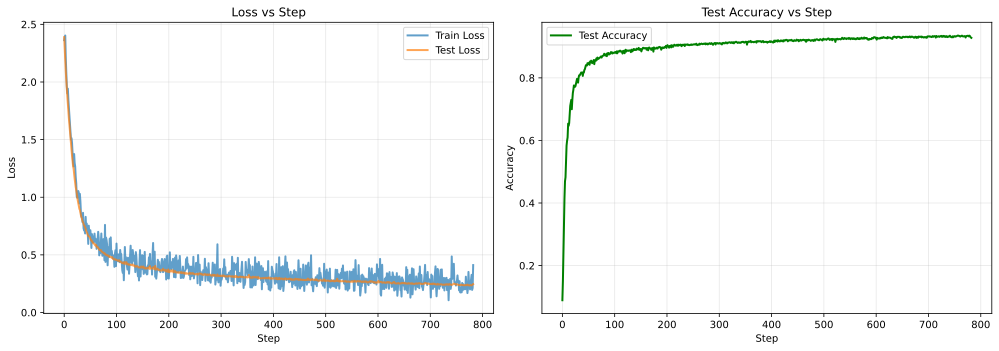

In [ ]:
# ==========================================
# 6. 可视化 (Visualization)
# ==========================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss 曲线
ax1.plot(history['step'], history['train_loss'], label='Train Loss', alpha=0.7, lw=2)
ax1.plot(history['step'], history['test_loss'], label='Test Loss', alpha=0.7, lw=2)
ax1.set_xlabel('Step')
ax1.set_ylabel('Loss')
ax1.set_title('Loss vs Step')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy 曲线
ax2.plot(history['step'], history['test_acc'], label='Test Accuracy', color='green', lw=2)
ax2.set_xlabel('Step')
ax2.set_ylabel('Accuracy')
ax2.set_title('Test Accuracy vs Step')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


演示预测单个样本:
真实标签: 6
模型预测: 6 (置信度: 72.39%)


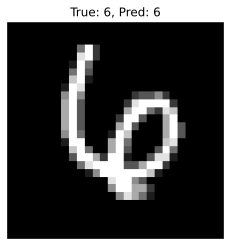

In [36]:
# 简单的推理演示
print("\n演示预测单个样本:")
sample_idx = 22
img = X_test[sample_idx]
true_label = y_test[sample_idx].item()

# 前向计算
logits = relu(img @ W1 + b1) @ W2 + b2
probs = softmax(logits.unsqueeze(0)) # 增加 batch 维度
pred_label = torch.argmax(probs).item()

print(f"真实标签: {true_label}")
print(f"模型预测: {pred_label} (置信度: {probs[0][pred_label]:.2%})")

# 将展平的向量还原回 28x28 图片显示
plt.imshow(img.reshape(28, 28), cmap='gray')
plt.title(f"True: {true_label}, Pred: {pred_label}")
plt.axis('off')
plt.show()